# Trayectorias de falsos bosques

La clase **3** debería persistir al menos **tres años seguidos**. Cuando aparece uno o dos años aislados entre otras coberturas, la trayectoria es inconsistente.

**Archivos locales:** `regiones.xlsx` (columna 1, sin encabezado) y `leyenda_coleccion3.json`.

**Modos:** `REGION_ID = None` → exportar todas las regiones a CSV. `REGION_ID = '30453'` → mapa de una región.


## Reglas de corrección

Ventana de **cuatro años consecutivos** por píxel: `t−1`, `t`, `t+1`, `t+2`.  
Solo se analiza y corrige la clase **3** (bosque) en el año central `t`.

### 1. Qué se considera anomalía

| Tipo | Patrón (4 años) | Condición sobre el bosque en `t` |
|------|-----------------|----------------------------------|
| **Bosque aislado 1 año** | `X → 3 → Y → …` | `X ≠ 3`, `Y ≠ 3` |
| **Bosque aislado 2 años** | `X → 3 → 3 → Y` | `X ≠ 3`, `Y ≠ 3` (el primer o el segundo `3` del bloque) |

Ejemplos con códigos LULC frecuentes:

| Códigos | Nombre (leyenda) | ¿Anomalía? |
|---------|------------------|------------|
| `33-3-33-33` | Agua → Bosque → Agua → Agua | Sí, 1 año |
| `21-3-21-21` | Mosaico → Bosque → Mosaico → Mosaico | Sí, 1 año |
| `33-3-3-33` | Agua → Bosque → Bosque → Agua | Sí, 2 años |
| `33-3-3-21` | Agua → Bosque → Bosque → Mosaico | Sí, 2 años |
| `3-3-3-21` | Bosque persistente | No |
| `21-3-35-35` | Mosaico → Bosque → Palma → Palma | Sí, 1 año |

### 2. Cómo se corrige el año `t`

Solo los píxeles marcados como anomalía cambian el valor en `t`. El resto de la serie no se toca.

**Regla de reemplazo — bosque aislado de 1 año** (`error1`, `X → 3 → Y`, `Y ≠ 3`):

| Prioridad | Si se cumple… | El `3` en `t` pasa a… |
|-----------|---------------|------------------------|
| 1 | `t+1` es **9** o **35** | clase de `t+1` |
| 2 | Cualquier otro caso | clase de `t−1` |

**No se usa `t+2`** en bosque de 1 año: `21-3-21-35` → `21-21-21-35`.

Matriz resumida (1 año):

| `t−1` (X) | `t+1` (Y) | `t+2` | Valor corregido en `t` |
|-----------|-----------|-------|-------------------------|
| 33 | 33 | cualquiera | **33** |
| 21 | 21 | cualquiera | **21** |
| 21 | 35 | cualquiera | **35** |
| 21 | 21 | 35 o 9 | **21** (`t+2` no cuenta) |
| 33 | 21 | — | **33** |

#### Bosque aislado de **2 años** (`X → 3 → 3 → Y`)

Se corrigen **los dos** años con bosque, cada uno con una regla distinta:

| Año corregido | Regla en código | Qué mira | Reemplazo |
|---------------|-----------------|----------|-----------|
| **Primer `3`** (inicio del bloque) | `error2_ini` | `t−1`, `t`, `t+1` | `reemplazo(t−1, t+1)` — plantación solo si está en `t+1`; si no, **t−1** |
| **Segundo `3`** (fin del bloque) | `error2_fin` | `t−2`, `t−1`, `t`, `t+1` | `reemplazo(t−2, t+1)` — misma regla; si no hay plantación en `t+1`, usa **t−2** |

Matriz para el patrón `33 → 3 → 3 → 21` (agua, dos bosques, mosaico):

| Año | Valor antes | Regla | Cálculo | Valor después |
|-----|-------------|-------|---------|---------------|
| 1 | 33 | — | sin cambio | 33 |
| 2 | **3** | error2_ini | `reemplazo_2anio_ini(33, 3, 21)` → 21 no es plantación → **33** | 33 |
| 3 | **3** | error2_fin | `reemplazo(33, 21)` → 21 no es plantación → **33** | 33 |
| 4 | 21 | — | sin cambio | 21 |

```
Antes:   33   3   3   21
              ↑   ↑
         error2_ini  error2_fin

Después: 33  33  33  21
```

Si el cuarto año fuera plantación (`33-3-3-35`), el **primer** `3` pasa a **33** (`t+1` es otro bosque, no plantación), y el **segundo** `3` a **35** (plantación en `t+1`):

```
Antes:   33   3   3   35
Después: 33  33  35  35
```

### 3. Ejemplos paso a paso

**Ejemplo A — agua con bosque de un año**

```
Antes:   33   3   33   33
         ↑    ↑
        t−1   t  ← anomalía detectada

Después: 33  33  33  33
              ↑
         3 reemplazado por 33 (clase de t−1)
```

**Ejemplo B — mosaico hacia palma**

```
Antes:   21   3   35   35
Después: 21  35   35   35
              ↑
         3 reemplazado por 35 (plantación en t+1)
```

**Ejemplo B′ — plantación solo en `t+2` (no se corrige hacia ella)**

```
Antes:   21   3   21   35
Después: 21  21   21   35
              ↑
         3 reemplazado por 21 (t+1 no es plantación; t+2 no cuenta)

Igual con silvicultura: 21-3-21-9 → 21-21-21-9
```

**Ejemplo C — `33-3-3-21` (agua, dos bosques, mosaico)**

Caso típico de bosque aislado 2 años. Ambos `3` se reemplazan por **33** (agua del entorno); el mosaico en el año 4 no se usa como valor de reemplazo porque no es plantación (9/35).

```
Antes:   33   3   3   21
Después: 33  33  33  21
```

**Ejemplo D — `33-3-3-33` (agua en ambos extremos)**

Misma lógica que C, pero el año 4 también es agua. A veces la **1ª pasada** deja un `3` suelto (`33-33-3-33`); la **2ª pasada** lo corrige:

```
Antes:      33   3   3   33
1ª pasada:  33  33   3  33   ← puede quedar un 3 residual
2ª pasada:  33  33  33  33
```

Por eso la corrección se aplica en **dos pasadas** sobre el mosaico completo: una sola pasada dejaba bosque suelto cuando había varios años falsos seguidos.

**¿Corregir primero 1 año y luego 2 años?** No hace falta un orden especial entre tipos de anomalía. En cada pasada se evalúan `error1`, `error2_ini` y `error2_fin` sobre la imagen ya parcialmente corregida; las máscaras no se solapan en el mismo año. Lo que importa es repetir la pasada completa (no separar por tipo), para que un `3` residual —por ejemplo tras `33-3-3-33`— se detecte en la segunda lectura.

### 4. Años que entran en la corrección

| Años | Tratamiento |
|------|-------------|
| 1987 – 2023 | Regla completa (ventana de 4 años) |
| 1986, 2024 | Solo borde: detecta `X→3→Y` sin `t+2` |
| 1985, 2025, … | Sin corrección (se copian tal cual) |

La detección en mapa y CSV usa 1986–2023; la corrección escribe bandas 1986–2024.

### 5. Qué no se corrige

- Bosque que ya dura **3 años o más** (`3-3-3-…`).
- Clases distintas de **3** (no se modifican otros usos del suelo).
- Patrones fuera de la ventana de años indicada.

### 6. Flujo en el notebook

```
Original  →  detectar anomalías  →  corregir (2 pasadas)  →  Corregida
                ↓                                              ↓
         tabla / mapa "Original"                    botón "Ver corregida"
```

En el mapa, **Original** muestra los falsos bosques del asset fuente; **Corregida** recalcula la detección sobre `IMG_CORREGIDA`. Si la corrección funcionó, los patrones `X→3→Y` deberían desaparecer o reducirse drásticamente.

## 1. Conexión a Earth Engine

In [1]:
import ee

GEE_PROJECT = 'mapbiomas-colombia'

if 'ee_initialized' not in globals():
    # ee.Authenticate()  # descomentar solo la primera vez
    ee.Initialize(project=GEE_PROJECT)
    ee_initialized = True
    print(f'Conectado a GEE — proyecto: {GEE_PROJECT}')
else:
    print('GEE ya inicializado en esta sesión.')

Conectado a GEE — proyecto: mapbiomas-colombia


## 2. Configuración

`REGION_ID` define el modo: `None` recorre el Excel

In [60]:
import re
import json
from pathlib import Path
import pandas as pd
FOLDER = 'projects/mapbiomas-colombia/assets/LULC/COLECCION4/clasificacion-ft'
REGIONES_XLSX = Path('regiones.xlsx')
REGION_ID = 30453  # None = todas las regiones; p. ej. '30205' para el mapa
YEARS = ee.List.sequence(1986, 2023)
CLASE_BOSQUE = 3
CLASES_PLANTACION = (9, 35)

LEYENDA_PATH = Path('leyenda_coleccion3.json')
with open(LEYENDA_PATH, encoding='utf-8') as f:
    _leyenda = json.load(f)
CLASS_NAMES = {int(k): v for k, v in _leyenda['class_names'].items()}
PALETTE_LULC = _leyenda['palette_lulc']

VIS_ANOMALIAS = {'min': 1, 'max': 4, 'palette': ['#fee08b', '#fdae61', '#f46d43', '#a50026']}
LEGEND_ANOMALIAS = {
    '1 detección': 'fee08b',
    '2 detecciones': 'fdae61',
    '3 detecciones': 'f46d43',
    '4+ detecciones': 'a50026',
}
VIS_LULC = {'min': 0, 'max': len(PALETTE_LULC) - 1, 'palette': PALETTE_LULC}


## 3. Funciones

Implementación en Earth Engine: detección (`anomalia_bosque`), reemplazo de 1 año (`reemplazo_falso_bosque`), reemplazo del primer año de bloque de 2 (`reemplazo_falso_bosque_2anio_ini`) y corrección en dos pasadas (`corregir_falsos_bosques`).

In [61]:

def class_name(class_id):
    return CLASS_NAMES.get(int(class_id), f'Clase {int(class_id)}')


def lulc_color(class_id):
    idx = int(class_id)
    return PALETTE_LULC[idx] if 0 <= idx < len(PALETTE_LULC) else '#888888'


def band_name(year):
    return ee.String('classification_').cat(ee.Number(year).format('%d'))


def es_plantacion(img):
    return img.eq(9).Or(img.eq(35))


def reemplazo_falso_bosque(prev, next1):
    """Bosque aislado 1 año (o 2º año del bloque): plantación solo en t+1; si no, t−1."""
    rep = ee.Image(prev)
    return rep.where(next1.eq(9), 9).where(next1.eq(35), 35)


def reemplazo_falso_bosque_2anio_ini(prev, next1, next2):
    """Primer 3 de bloque de 2 años: si t+1 es otro bosque y t+2 es plantación, usar t+2."""
    rep = ee.Image(prev)
    rep = rep.where(next1.eq(9), 9).where(next1.eq(35), 35)
    seguido_de_bosque = next1.eq(CLASE_BOSQUE)
    rep = rep.where(seguido_de_bosque.And(next2.eq(9)), 9)
    rep = rep.where(seguido_de_bosque.And(next2.eq(35)), 35)
    return rep


def anomalia_bosque(prev1, curr, next1, next2):
    """Misma detección que corregir_falsos_bosques: bosque aislado 1 o 2 años."""
    error1 = prev1.neq(CLASE_BOSQUE).And(curr.eq(CLASE_BOSQUE)).And(next1.neq(CLASE_BOSQUE))
    error2_ini = prev1.neq(CLASE_BOSQUE).And(curr.eq(CLASE_BOSQUE)).And(next1.eq(CLASE_BOSQUE)).And(next2.neq(CLASE_BOSQUE))
    return error1.Or(error2_ini)


def describe_trayectoria(p1, c, n1, n2):
    p1, c, n1, n2 = map(int, (p1, c, n1, n2))
    if c != CLASE_BOSQUE:
        return 'Sin bosque aislado'
    if n1 != CLASE_BOSQUE and n2 != CLASE_BOSQUE:
        return 'Bosque aislado 1 año'
    if n1 == CLASE_BOSQUE and n2 != CLASE_BOSQUE:
        return 'Bosque aislado 2 años'
    return 'Revisar patrón'


def codigo_clases(p1, c, n1, n2):
    p1, c, n1, n2 = map(int, (p1, c, n1, n2))
    return f'{p1}-{c}-{n1}-{n2}'


def codigo_desde_k(k):
    k = int(float(k))
    return codigo_clases(
        k // 1_000_000,
        (k % 1_000_000) // 10_000,
        (k % 10_000) // 100,
        k % 100,
    )


def parse_trajectory(code):
    k = int(float(code))
    p1, c, n1, n2 = k // 1_000_000, (k % 1_000_000) // 10_000, (k % 10_000) // 100, k % 100
    ids = codigo_clases(p1, c, n1, n2)
    return {
        'codigo': k,
        'clase_1': p1, 'clase_2': c, 'clase_3': n1, 'clase_4': n2,
        'clases': ids,
        'trayectoria': ids,
        'tipo': describe_trayectoria(p1, c, n1, n2),
    }


def cargar_asset_region(region_id, folder=FOLDER):
    """Busca COLOMBIA-{region_id}-{version} en GEE; region_id viene del Excel."""
    rid = str(region_id).strip()
    prefix = f'COLOMBIA-{rid}-'
    assets = ee.data.listAssets({'parent': folder})['assets']
    matches = []
    for a in assets:
        base = a['name'].split('/')[-1]
        if not base.startswith(prefix):
            continue
        ver = base[len(prefix):]
        if ver.isdigit() and int(ver) != 11:
            matches.append(a)
    matches = sorted(matches, key=lambda a: int(a['name'].split('/')[-1].rsplit('-', 1)[-1]), reverse=True)
    if not matches:
        return None, None
    name = matches[0]['name']
    return ee.Image(name), name


def histograma_trayectorias(imagen):
    def mapear_anomalias(y):
        year = ee.Number(y)
        prev1 = imagen.select(band_name(year.subtract(1)))
        curr = imagen.select(band_name(year))
        next1 = imagen.select(band_name(year.add(1)))
        next2 = imagen.select(band_name(year.add(2)))
        anomalia = anomalia_bosque(prev1, curr, next1, next2)
        trayectoria = prev1.multiply(1_000_000).add(curr.multiply(10_000)).add(next1.multiply(100)).add(next2)
        return ee.Image([anomalia.rename('error'), trayectoria.updateMask(anomalia).rename('trajectory')])

    errores = ee.ImageCollection.fromImages(YEARS.map(mapear_anomalias))
    trajectories_img = errores.select('trajectory').max()
    hist = trajectories_img.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=imagen.geometry(), scale=30, maxPixels=1e10, bestEffort=True,
    ).getInfo()
    return hist.get('trajectory') or {}


def ids_desde_regiones(path='regiones.xlsx'):
    """Lee IDs de región desde la primera columna del xlsx (sin encabezado), en orden del archivo."""
    col = pd.read_excel(path, header=None, usecols=[0]).iloc[:, 0].dropna()
    ids = col.astype(int).astype(str).drop_duplicates().tolist()
    if not ids:
        raise ValueError(f'No se encontraron IDs de región en {path}')
    return ids


def corregir_falsos_bosques(imagen, pasadas=2):
    """Corrige falsos bosques por año. Dos pasadas: la primera puede dejar
    bosque residual en bloques largos; la segunda limpia esas ventanas."""

    def corregir_borde(img, y):
        curr = img.select(band_name(y))
        prev1 = img.select(band_name(ee.Number(y).subtract(1)))
        next1 = img.select(band_name(ee.Number(y).add(1)))
        error = prev1.neq(CLASE_BOSQUE).And(curr.eq(CLASE_BOSQUE)).And(next1.neq(CLASE_BOSQUE))
        return curr.where(error, reemplazo_falso_bosque(prev1, next1))

    def corregir_medio(img, y):
        curr = img.select(band_name(y))
        prev1 = img.select(band_name(ee.Number(y).subtract(1)))
        prev2 = img.select(band_name(ee.Number(y).subtract(2)))
        next1 = img.select(band_name(ee.Number(y).add(1)))
        next2 = img.select(band_name(ee.Number(y).add(2)))
        error1 = prev1.neq(CLASE_BOSQUE).And(curr.eq(CLASE_BOSQUE)).And(next1.neq(CLASE_BOSQUE))
        error2_ini = prev1.neq(CLASE_BOSQUE).And(curr.eq(CLASE_BOSQUE)).And(next1.eq(CLASE_BOSQUE)).And(next2.neq(CLASE_BOSQUE))
        error2_fin = prev2.neq(CLASE_BOSQUE).And(prev1.eq(CLASE_BOSQUE)).And(curr.eq(CLASE_BOSQUE)).And(next1.neq(CLASE_BOSQUE))
        return curr \
            .where(error1, reemplazo_falso_bosque(prev1, next1)) \
            .where(error2_ini, reemplazo_falso_bosque_2anio_ini(prev1, next1, next2)) \
            .where(error2_fin, reemplazo_falso_bosque(prev2, next1))

    def _paso(img):
        bandas = []
        for nombre in img.bandNames().getInfo():
            y = int(nombre.split('_')[1])
            if y < 1986 or y > 2024:
                bandas.append(img.select(nombre))
            elif y in (1986, 2024):
                bandas.append(corregir_borde(img, y))
            else:
                bandas.append(corregir_medio(img, y))
        return ee.Image.cat(bandas).toByte().rename(img.bandNames())

    result = imagen
    for _ in range(pasadas):
        result = _paso(result)
    return result


## 4. Carga de datos

Ejecutar siempre después de cambiar `REGION_ID`.

In [62]:

if not REGIONES_XLSX.exists():
    raise FileNotFoundError(f'Coloca {REGIONES_XLSX} en la carpeta del proyecto')

REGION_IDS = ids_desde_regiones(REGIONES_XLSX)
MODO_MAPA = REGION_ID is not None

print(f'Leyenda: {len(CLASS_NAMES)} clases desde {_leyenda["source"]}')
print(f'Regiones en {REGIONES_XLSX.name}: {len(REGION_IDS)}')

if MODO_MAPA:
    rid = str(REGION_ID)
    if rid not in REGION_IDS:
        print(f'Aviso: {rid} no aparece en {REGIONES_XLSX.name}')
    IMG_ORIGINAL, ASSET_ORIGINAL = cargar_asset_region(rid)
    if IMG_ORIGINAL is None:
        raise ValueError(f'No hay asset LULC para la región {rid}')
    IMG_CORREGIDA = corregir_falsos_bosques(IMG_ORIGINAL)
    print(f'Región cargada: {rid}')
    print(f'Asset: {ASSET_ORIGINAL}')
else:
    IMG_ORIGINAL = IMG_CORREGIDA = None
    ASSET_ORIGINAL = None
    print('Listo para exportar por regiones.')
    print('Para el mapa: asigna REGION_ID y vuelve a ejecutar esta celda.')


Leyenda: 31 clases desde Codigo-de-la-Leyenda-coleccion-3.pdf
Regiones en regiones.xlsx: 155
Región cargada: 30453
Asset: projects/mapbiomas-colombia/assets/LULC/COLECCION4/clasificacion-ft/COLOMBIA-30453-10


## 5. Exportar por regiones

Escribe 	rayectorias_imposibles_por_region.csv. Solo con REGION_ID = None.


In [58]:
if MODO_MAPA:
    print('Modo mapa activo: esta celda es para el procesamiento por lotes (REGION_ID = None).')
else:
    OUTPUT_CSV = Path('trayectorias_imposibles_por_region.csv')

    region_ids = REGION_IDS
    print(f'Regiones en Excel: {len(region_ids)}')

    filas = []
    omitidas = []
    sin_anomalias = []

    for i, rid in enumerate(region_ids, 1):
        print(f'[{i}/{len(region_ids)}] {rid}...', end=' ')
        try:
            img, asset = cargar_asset_region(rid)
        except Exception as err:
            print(f'error ({err})')
            omitidas.append({'region_id': rid, 'motivo': str(err)})
            continue
        if img is None:
            print('sin asset')
            omitidas.append({'region_id': rid, 'motivo': 'sin asset'})
            continue
        try:
            hist = histograma_trayectorias(img)
        except Exception as err:
            print(f'error GEE ({err})')
            omitidas.append({'region_id': rid, 'motivo': str(err), 'asset': asset})
            continue
        if not hist:
            print('sin anomalias')
            sin_anomalias.append(rid)
            continue
        for codigo, pixeles in hist.items():
            filas.append({
                'region_id': rid,
                'asset': asset,
                **parse_trajectory(codigo),
                'pixeles': int(pixeles),
            })
        print(f'{len(hist)} patrones')

    df_tray = pd.DataFrame(filas).sort_values(['region_id', 'pixeles'], ascending=[True, False])
    df_tray.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
    print(f'\nGuardado: {OUTPUT_CSV.resolve()}')
    n_reg = df_tray['region_id'].nunique() if len(df_tray) else 0
    print(f'Filas: {len(df_tray):,} · Regiones con datos: {n_reg}')
    print(f'Omitidas: {len(omitidas)} · Sin anomalias: {len(sin_anomalias)}')
    if omitidas:
        display(pd.DataFrame(omitidas).head(10))
    df_tray.head(10)

Modo mapa activo: esta celda es para el procesamiento por lotes (REGION_ID = None).


## 6. Análisis del CSV

No requiere Earth Engine. Incluye gráficos globales y, al final, las **5 trayectorias más frecuentes** en cada una de las **5 regiones** con más píxeles anómalos.


Resumen del CSV
Filas en CSV:        5,810
Regiones con datos:  56
Patrones distintos:  1,129
Pixeles afectados:   9,623,360
Media px/patron:     8,524
Mediana px/patron:   23

Por tipo de anomalia (pixeles):
  Bosque aislado 2 años: 5,867,603 (61.0%)
  Bosque aislado 1 año: 3,508,150 (36.5%)
  Revisar patrón: 247,607 (2.6%)


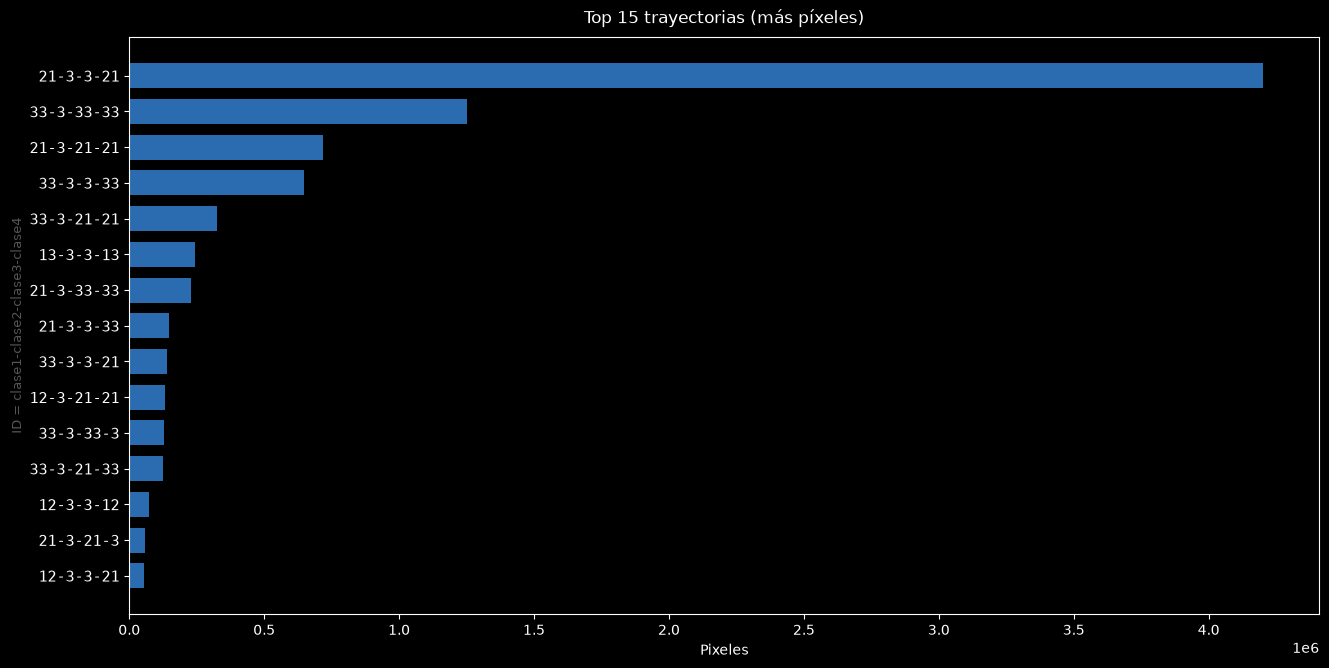

#,clases,tipo,pixeles,regiones
1,21-3-3-21,Bosque aislado 2 años,4199898,55
2,33-3-33-33,Bosque aislado 1 año,1252263,53
3,21-3-21-21,Bosque aislado 1 año,718196,50
4,33-3-3-33,Bosque aislado 2 años,646680,53
5,33-3-21-21,Bosque aislado 1 año,326884,51
6,13-3-3-13,Bosque aislado 2 años,242383,28
7,21-3-33-33,Bosque aislado 1 año,227070,52
8,21-3-3-33,Bosque aislado 2 años,148787,51
9,33-3-3-21,Bosque aislado 2 años,141042,49
10,12-3-21-21,Bosque aislado 1 año,130564,10


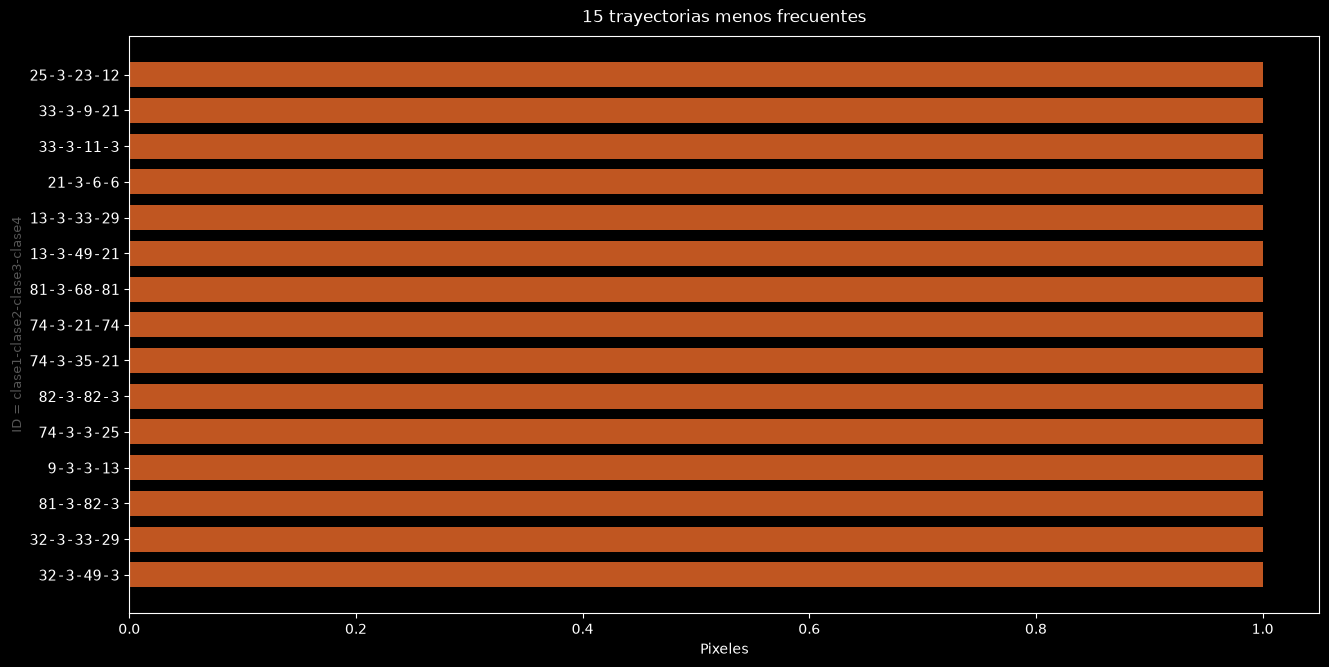

#,clases,tipo,pixeles,regiones
1,25-3-23-12,Bosque aislado 1 año,1,1
2,33-3-9-21,Bosque aislado 1 año,1,1
3,33-3-11-3,Revisar patrón,1,1
4,21-3-6-6,Bosque aislado 1 año,1,1
5,13-3-33-29,Bosque aislado 1 año,1,1
6,13-3-49-21,Bosque aislado 1 año,1,1
7,81-3-68-81,Bosque aislado 1 año,1,1
8,74-3-21-74,Bosque aislado 1 año,1,1
9,74-3-35-21,Bosque aislado 1 año,1,1
10,82-3-82-3,Revisar patrón,1,1


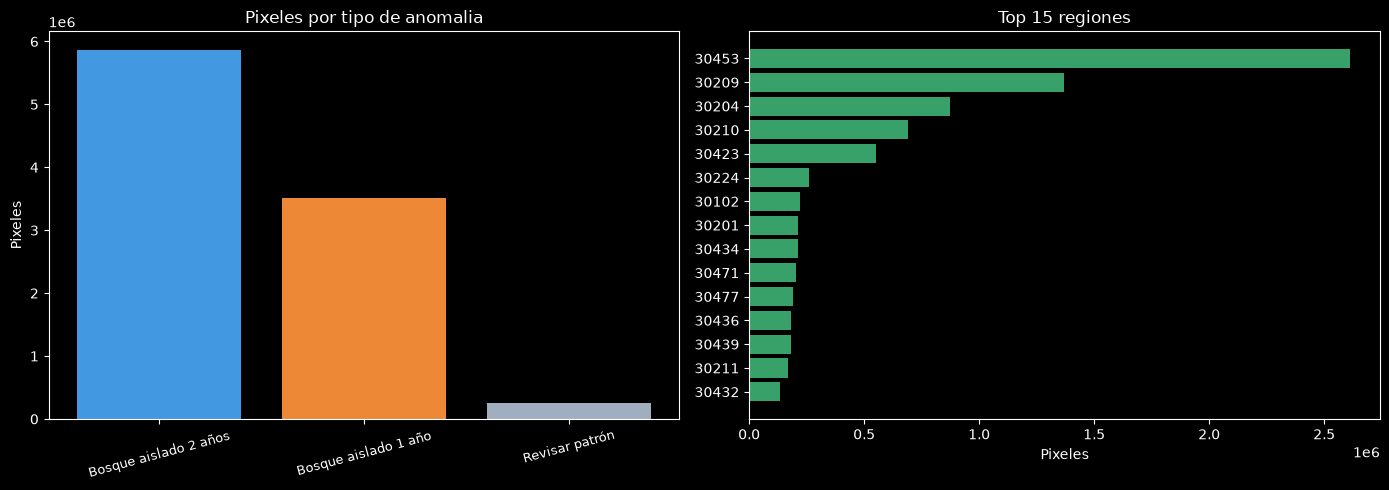

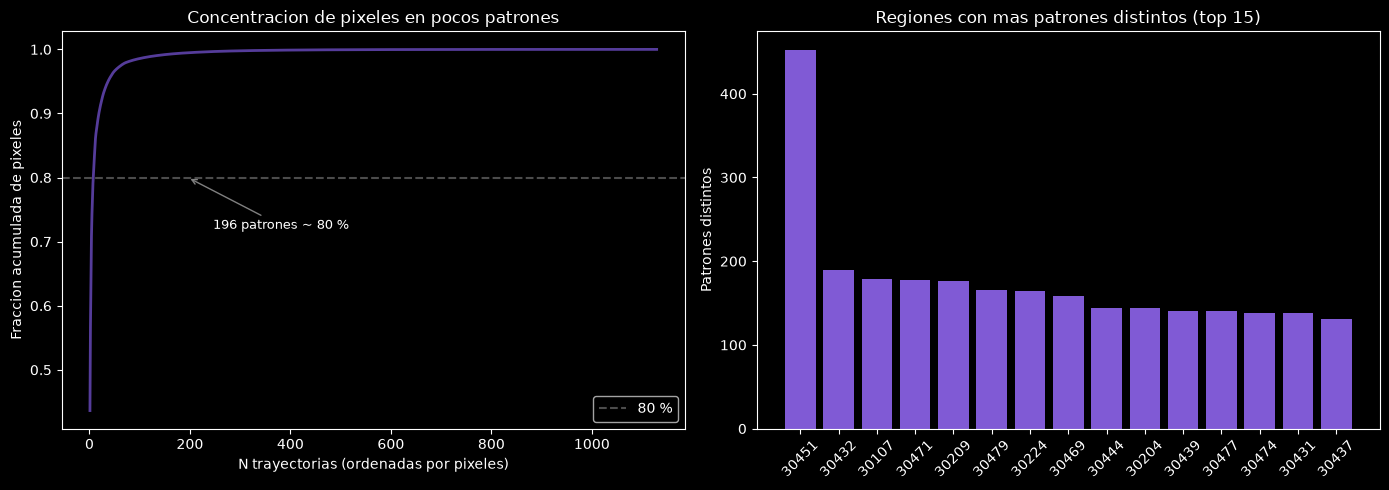

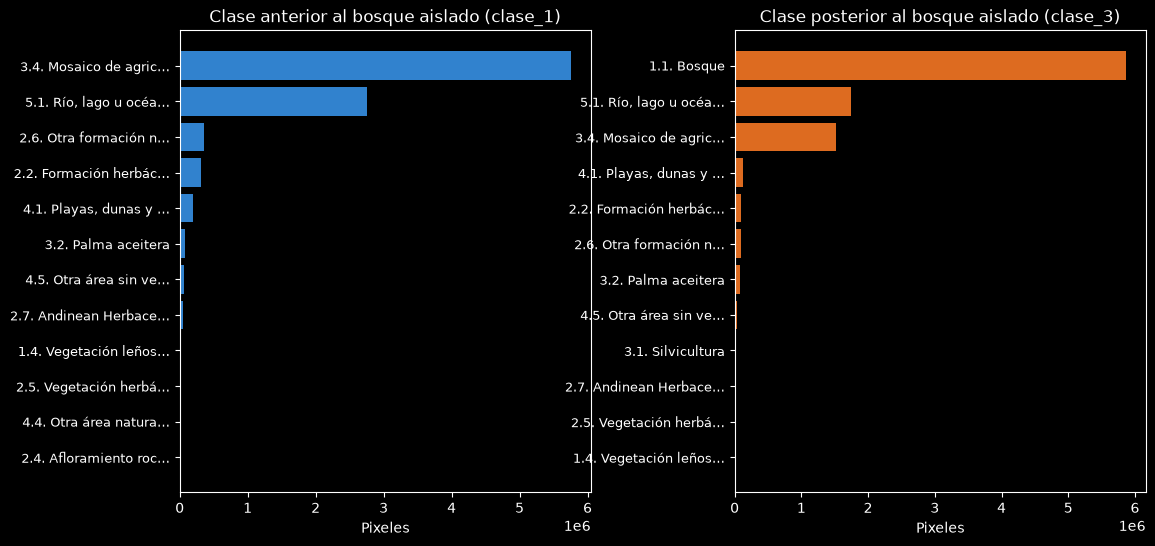

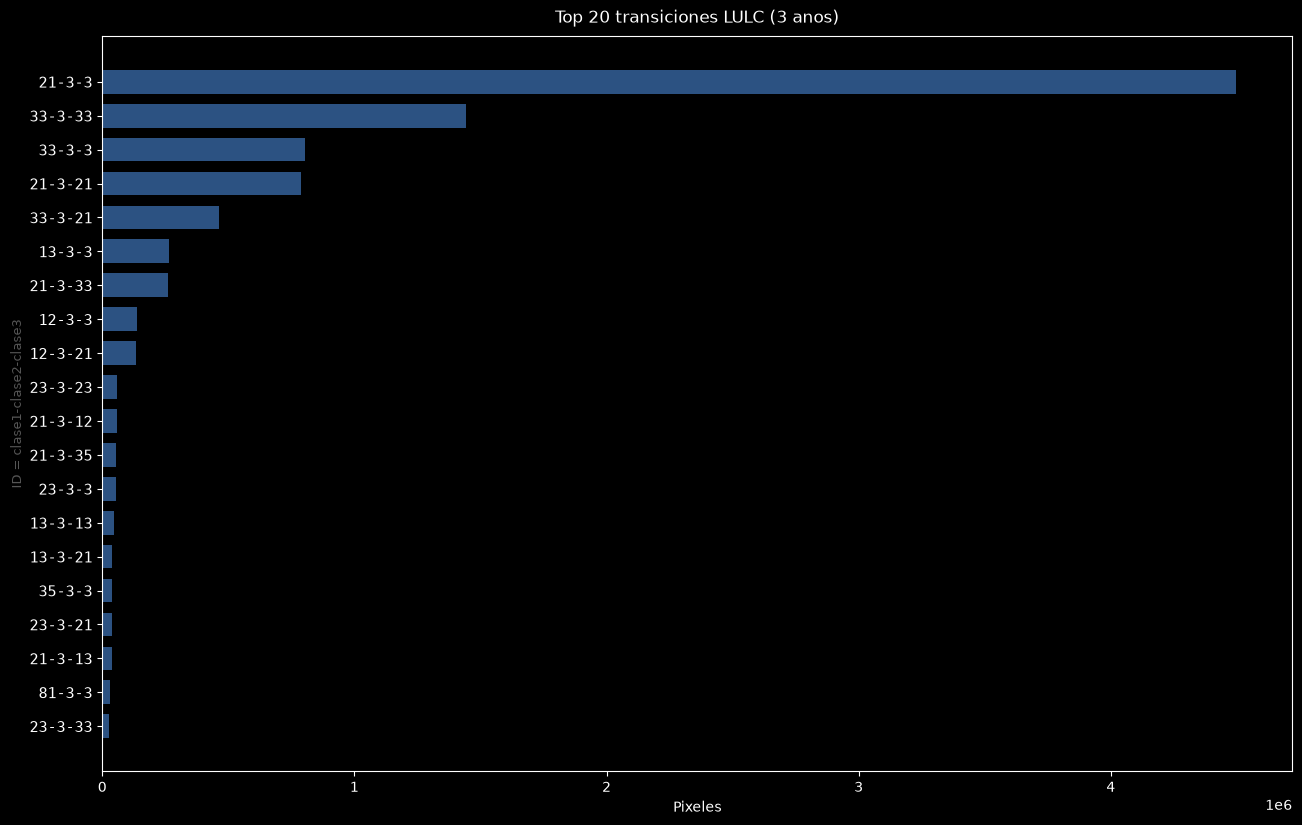

#,clases,pixeles
1,21-3-3,4494961
2,33-3-33,1440615
3,33-3-3,804888
4,21-3-21,786777
5,33-3-21,461053
6,13-3-3,266596
7,21-3-33,258891
8,12-3-3,138611
9,12-3-21,134219
10,23-3-23,60361


Top 10 trayectorias


,clases,tipo,pixeles,regiones
189,21-3-3-21,Bosque aislado 2 años,4199898,55
803,33-3-33-33,Bosque aislado 1 año,1252263,53
234,21-3-21-21,Bosque aislado 1 año,718196,50
701,33-3-3-33,Bosque aislado 2 años,646680,53
735,33-3-21-21,Bosque aislado 1 año,326884,51
116,13-3-3-13,Bosque aislado 2 años,242383,28
287,21-3-33-33,Bosque aislado 1 año,227070,52
195,21-3-3-33,Bosque aislado 2 años,148787,51
695,33-3-3-21,Bosque aislado 2 años,141042,49
82,12-3-21-21,Bosque aislado 1 año,130564,10


Trayectorias mas raras


,clases,tipo,pixeles,regiones
179,13-3-49-21,Bosque aislado 1 año,1,1
1114,81-3-68-81,Bosque aislado 1 año,1,1
1080,74-3-21-74,Bosque aislado 1 año,1,1
1084,74-3-35-21,Bosque aislado 1 año,1,1
1127,82-3-82-3,Revisar patrón,1,1
1073,74-3-3-25,Bosque aislado 2 años,1,1
19,9-3-3-13,Bosque aislado 2 años,1,1
1121,81-3-82-3,Revisar patrón,1,1
671,32-3-33-29,Bosque aislado 1 año,1,1
676,32-3-49-3,Revisar patrón,1,1


...


Region 30423 — 552,539 pixeles · 95 patrones distintos


clases,tipo,pixeles,pct_region
21-3-3-21,Bosque aislado 2 años,"468,233",84.7%
21-3-21-21,Bosque aislado 1 año,"61,668",11.2%
21-3-13-13,Bosque aislado 1 año,"3,005",0.5%
13-3-21-21,Bosque aislado 1 año,"2,429",0.4%
21-3-33-33,Bosque aislado 1 año,"2,357",0.4%


Regiones con mas y menos pixeles


,region_id,pixeles,patrones
37,30453,2611880,128
10,30209,1367888,176
7,30204,871123,144
11,30210,690477,114
18,30423,552539,95


,region_id,pixeles,patrones
35,30447,3379,82
41,30462,2437,68
38,30456,2219,34
5,30108,1120,20
55,30493,4,1


In [69]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CSV_EDA = Path('trayectorias_imposibles_por_region.csv')
if not CSV_EDA.exists():
    raise FileNotFoundError(f'Genera primero {CSV_EDA} con la celda anterior.')

df_eda = pd.read_csv(CSV_EDA, encoding='utf-8-sig')
df_eda['region_id'] = df_eda['region_id'].astype(str)

if Path('leyenda_coleccion3.json').exists():
    with open('leyenda_coleccion3.json', encoding='utf-8') as f:
        _cn = {int(k): v for k, v in json.load(f)['class_names'].items()}

    def _nombre(c):
        return _cn.get(int(c), f'Clase {int(c)}')
else:
    def _nombre(c):
        return f'Clase {int(c)}'

def _codigo_desde_k(k):
    k = int(float(k))
    return f'{k // 1_000_000}-{(k % 1_000_000) // 10_000}-{(k % 10_000) // 100}-{k % 100}'

df_eda['clases'] = df_eda['codigo'].apply(_codigo_desde_k)

por_tray = (
    df_eda.groupby(['codigo', 'clases', 'tipo'], as_index=False)
    .agg(pixeles=('pixeles', 'sum'), regiones=('region_id', 'nunique'))
    .sort_values('pixeles', ascending=False)
)

por_region = (
    df_eda.groupby('region_id', as_index=False)
    .agg(pixeles=('pixeles', 'sum'), patrones=('codigo', 'nunique'))
    .sort_values('pixeles', ascending=False)
)

por_tipo = df_eda.groupby('tipo', as_index=False)['pixeles'].sum().sort_values('pixeles', ascending=False)

total_px = int(df_eda['pixeles'].sum())
print('Resumen del CSV')
print(f'Filas en CSV:        {len(df_eda):,}')
print(f'Regiones con datos:  {df_eda["region_id"].nunique()}')
print(f'Patrones distintos:  {df_eda["codigo"].nunique():,}')
print(f'Pixeles afectados:   {total_px:,}')
print(f'Media px/patron:     {df_eda.groupby("codigo")["pixeles"].sum().mean():,.0f}')
print(f'Mediana px/patron:   {df_eda.groupby("codigo")["pixeles"].sum().median():,.0f}')
print()
print('Por tipo de anomalia (pixeles):')
for _, row in por_tipo.iterrows():
    pct = 100 * row['pixeles'] / total_px
    print(f"  {row['tipo']}: {int(row['pixeles']):,} ({pct:.1f}%)")

TOP_N = 15


def _abrev(texto, max_len=18):
    t = str(texto)
    return t if len(t) <= max_len else t[: max_len - 1] + '…'


def _barh_con_leyenda(df_plot, titulo, color, nota='ID = clase1-clase2-clase3-clase4', cols=None):
    """Barras con ID en el eje Y; tabla debajo."""
    cols = cols or ['clases', 'tipo', 'pixeles', 'regiones']
    n = len(df_plot)
    alto = max(5, 0.45 * n + 1.5)
    fig, ax = plt.subplots(figsize=(14, alto))
    ax.barh(range(n), df_plot['pixeles'], color=color, height=0.7)
    ax.set_yticks(range(n), df_plot['clases'], fontsize=11, family='monospace')
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=12, pad=10)
    ax.set_xlabel('Pixeles')
    ax.set_ylabel(nota, fontsize=9, color='#555')
    fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.22)
    plt.show()

    leyenda = df_plot[cols].copy()
    leyenda.insert(0, '#', range(1, n + 1))
    display(leyenda.style.hide(axis='index').set_properties(**{'text-align': 'left'}))


_barh_con_leyenda(
    por_tray.head(TOP_N),
    f'Top {TOP_N} trayectorias (más píxeles)',
    '#2b6cb0',
)

_barh_con_leyenda(
    por_tray[por_tray['pixeles'] > 0].tail(TOP_N).sort_values('pixeles'),
    f'{TOP_N} trayectorias menos frecuentes',
    '#c05621',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_tipo = ['#4299e1', '#ed8936', '#a0aec0']
axes[0].bar(por_tipo['tipo'], por_tipo['pixeles'], color=colors_tipo[: len(por_tipo)])
axes[0].set_title('Pixeles por tipo de anomalia')
axes[0].tick_params(axis='x', rotation=15, labelsize=9)
axes[0].set_ylabel('Pixeles')
top_reg = por_region.head(TOP_N)
axes[1].barh(range(len(top_reg)), top_reg['pixeles'], color='#38a169')
axes[1].set_yticks(range(len(top_reg)), top_reg['region_id'], fontsize=10)
axes[1].invert_yaxis()
axes[1].set_title(f'Top {TOP_N} regiones')
axes[1].set_xlabel('Pixeles')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum = por_tray['pixeles'].cumsum() / por_tray['pixeles'].sum()
axes[0].plot(np.arange(1, len(cum) + 1), cum.values, color='#553c9a', lw=2)
axes[0].axhline(0.8, color='gray', ls='--', alpha=0.6, label='80 %')
axes[0].set_xlabel('N trayectorias (ordenadas por pixeles)')
axes[0].set_ylabel('Fraccion acumulada de pixeles')
axes[0].set_title('Concentracion de pixeles en pocos patrones')
axes[0].legend()
n80 = int((cum >= 0.8).idxmax() + 1) if (cum >= 0.8).any() else len(cum)
axes[0].annotate(f'{n80} patrones ~ 80 %', xy=(n80, 0.8), fontsize=9, xytext=(n80 + 50, 0.72),
                 arrowprops=dict(arrowstyle='->', color='gray'))

div = por_region.sort_values('patrones', ascending=False).head(TOP_N)
axes[1].bar(div['region_id'], div['patrones'], color='#805ad5')
axes[1].set_title(f'Regiones con mas patrones distintos (top {TOP_N})')
axes[1].set_ylabel('Patrones distintos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

antes = df_eda.groupby('clase_1').apply(lambda g: g['pixeles'].sum(), include_groups=False)
antes = antes.sort_values(ascending=False).head(12)
axes[0].barh(range(len(antes)), antes.values, color='#3182ce')
axes[0].set_yticks(range(len(antes)), [_abrev(_nombre(c), 22) for c in antes.index], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Clase anterior al bosque aislado (clase_1)')
axes[0].set_xlabel('Pixeles')

despues = df_eda.groupby('clase_3').apply(lambda g: g['pixeles'].sum(), include_groups=False)
despues = despues.sort_values(ascending=False).head(12)
axes[1].barh(range(len(despues)), despues.values, color='#dd6b20')
axes[1].set_yticks(range(len(despues)), [_abrev(_nombre(c), 22) for c in despues.index], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('Clase posterior al bosque aislado (clase_3)')
axes[1].set_xlabel('Pixeles')

fig.subplots_adjust(left=0.28, right=0.97, wspace=0.35)
plt.show()

top_trans = (
    df_eda.groupby(['clase_1', 'clase_2', 'clase_3'], as_index=False)['pixeles']
    .sum()
    .sort_values('pixeles', ascending=False)
    .head(20)
)
top_trans['clases'] = top_trans.apply(
    lambda r: f"{int(r['clase_1'])}-{int(r['clase_2'])}-{int(r['clase_3'])}", axis=1
)

_barh_con_leyenda(
    top_trans,
    'Top 20 transiciones LULC (3 anos)',
    '#2c5282',
    nota='ID = clase1-clase2-clase3',
    cols=['clases', 'pixeles'],
)

print('Top 10 trayectorias')
display(por_tray[['clases', 'tipo', 'pixeles', 'regiones']].head(10))

print('Trayectorias mas raras')
display(por_tray[['clases', 'tipo', 'pixeles', 'regiones']].tail(10).sort_values('pixeles'))

TOP_REG = 5
TOP_TRAY_REG = 5
top5_regiones = por_region.head(TOP_REG)['region_id'].tolist()

print(f'Top {TOP_TRAY_REG} trayectorias en cada una de las {TOP_REG} regiones con mas pixeles')
for rid in top5_regiones:
    sub = (
        df_eda[df_eda['region_id'] == rid]
        .groupby(['codigo', 'clases', 'tipo'], as_index=False)['pixeles']
        .sum()
        .sort_values('pixeles', ascending=False)
        .head(TOP_TRAY_REG)
    )
    total_reg = int(por_region.loc[por_region['region_id'] == rid, 'pixeles'].iloc[0])
    sub['pct_region'] = (100 * sub['pixeles'] / total_reg).round(1)
    n_pat = int(por_region.loc[por_region['region_id'] == rid, 'patrones'].iloc[0])
    print(f'\nRegion {rid} — {total_reg:,} pixeles · {n_pat} patrones distintos')
    display(sub[['clases', 'tipo', 'pixeles', 'pct_region']].style.format({
        'pixeles': '{:,.0f}',
        'pct_region': '{:.1f}%',
    }).hide(axis='index'))

print('Regiones con mas y menos pixeles')
display(por_region.head(5))
display(por_region.tail(5))

## 7. Mapa interactivo

Requiere REGION_ID definido y celda de carga ejecutada.


In [ ]:

if not MODO_MAPA:
    from IPython.display import HTML, display
    display(HTML(
        '<p style="font-family:system-ui;color:#666">'
        'Sin mapa: asigna <code>REGION_ID</code> en Configuración y ejecuta la celda de carga.</p>'
    ))
else:
    import ipywidgets as widgets
    import leafmap
    from IPython.display import HTML, display

    state = {'current_img': IMG_ORIGINAL, 'trajectories_img': None, 'layers': [], 'fase': 'Original'}
    legend_added = False
    fase_label = widgets.HTML(value='<span style="color:#4a5568">Vista activa: <b>Original</b></span>')

    def _section_title(title, subtitle=''):
        sub = f'<div style="font-size:12px;color:#718096;margin-top:4px">{subtitle}</div>' if subtitle else ''
        return widgets.HTML(
            f'<div style="font-family:system-ui;width:100%;border-bottom:2px solid #2b6cb0;'
            f'padding:10px 0 8px 0;margin:20px 0 12px 0">'
            f'<div style="font-size:17px;font-weight:700;color:#1a365d">{title}</div>{sub}</div>'
        )

    chart_out = widgets.Output(layout=widgets.Layout(
        width='100%', min_height='520px', padding='20px',
        border='2px solid #2d3748', border_radius='10px', background_color='#111827',
    ))
    table_out = widgets.Output(layout=widgets.Layout(
        width='100%', min_height='380px', max_height='520px', overflow_y='auto',
        padding='16px', border='1px solid #cbd5e0', border_radius='10px',
    ))

    m = leafmap.Map(center=[4.5, -73.0], zoom=6, height='680px')
    m.layout = widgets.Layout(width='100%', height='680px', margin='0 0 8px 0')
    m.add_basemap('CartoDB.DarkMatter')
    m.add_layer_control(position='topright')

    TABLE_CSS = """
    <style>
    .traj-wrap { font-family: system-ui, sans-serif; }
    .traj-wrap h3 { margin: 0 0 12px 0; font-size: 15px; color: #1a202c; }
    .traj-wrap .meta { color: #718096; font-size: 12px; margin-bottom: 10px; }
    .traj-table { width: 100%; border-collapse: collapse; font-size: 12px; }
    .traj-table th {
        background: #2d3748; color: #fff; padding: 10px 8px; text-align: left;
        position: sticky; top: 0; z-index: 1;
    }
    .traj-table td { padding: 8px; border-bottom: 1px solid #e2e8f0; vertical-align: top; }
    .traj-table td.traj { max-width: 480px; line-height: 1.4; word-wrap: break-word; }
    .traj-table tr:nth-child(even) { background: #f8fafc; }
    .traj-table tr:hover { background: #edf2f7; }
    .traj-table .num { text-align: right; white-space: nowrap; font-variant-numeric: tabular-nums; }
    .empty { color: #718096; font-style: italic; padding: 24px 8px; }
    </style>
    """


    def quitar_capas_analisis():
        for name in state['layers']:
            layer = m.find_layer(name)
            if layer is not None:
                m.remove_layer(layer)
        state['layers'] = []
        marker = m.find_layer('Punto seleccionado')
        if marker is not None:
            m.remove_layer(marker)


    def mostrar_tabla_trayectorias(df, fase):
        total_pix = int(df['pixeles'].sum())
        show = df.head(15).copy()
        rows = []
        for _, r in show.iterrows():
            rows.append(
                f"<tr><td class='traj'>{r['trayectoria']}</td>"
                f"<td>{r['tipo']}</td>"
                f"<td class='num'>{int(r['pixeles']):,}</td></tr>"
            )
        body = ''.join(rows) if rows else "<tr><td colspan='3' class='empty'>Sin anomalías detectadas.</td></tr>"
        html = (
            f"{TABLE_CSS}<div class='traj-wrap'>"
            f"<h3>Trayectorias imposibles — {fase}</h3>"
            f"<div class='meta'>{len(df):,} patrones · {total_pix:,} píxeles anómalos · top 15</div>"
            f"<table class='traj-table'><thead><tr>"
            f"<th>ID trayectoria</th><th>Tipo</th><th>Píxeles</th>"
            f"</tr></thead><tbody>{body}</tbody></table></div>"
        )
        display(HTML(html))


    def analizar_imagen(imagen, fase):
        global legend_added
        state['current_img'] = imagen
        state['fase'] = fase
        fase_label.value = f'<span style="color:#4a5568">Vista activa: <b>{fase}</b></span>'
        quitar_capas_analisis()

        with table_out:
            table_out.clear_output(wait=True)
            display(HTML(f"{TABLE_CSS}<div class='traj-wrap'><h3>Trayectorias — {fase}</h3>"
                         f"<div class='meta'>Calculando…</div></div>"))

        def mapear_anomalias(y):
            year = ee.Number(y)
            prev1 = imagen.select(band_name(year.subtract(1)))
            curr = imagen.select(band_name(year))
            next1 = imagen.select(band_name(year.add(1)))
            next2 = imagen.select(band_name(year.add(2)))
            anomalia = anomalia_bosque(prev1, curr, next1, next2)
            trayectoria = prev1.multiply(1_000_000).add(curr.multiply(10_000)).add(next1.multiply(100)).add(next2)
            return ee.Image([anomalia.rename('error'), trayectoria.updateMask(anomalia).rename('trajectory')])

        errores = ee.ImageCollection.fromImages(YEARS.map(mapear_anomalias))
        frecuencia = errores.select('error').sum()
        frecuencia = frecuencia.where(frecuencia.gt(4), 4).selfMask()
        state['trajectories_img'] = errores.select('trajectory').max()

        m.add_ee_layer(imagen.select(band_name(2023)), VIS_LULC, name=f'LULC 2023 ({fase})', shown=False, opacity=0.35)
        m.add_ee_layer(frecuencia, VIS_ANOMALIAS, name=f'Bosque aislado ({fase})', shown=True, opacity=0.85)
        state['layers'] = [f'LULC 2023 ({fase})', f'Bosque aislado ({fase})']

        if not legend_added:
            m.add_legend(title='Frecuencia bosque aislado', legend_dict=LEGEND_ANOMALIAS, position='bottomleft')
            legend_added = True

        bounds = imagen.geometry().bounds().getInfo()['coordinates'][0]
        lats = [p[1] for p in bounds]
        lons = [p[0] for p in bounds]
        m.fit_bounds([[min(lats), min(lons)], [max(lats), max(lons)]])

        with table_out:
            table_out.clear_output(wait=True)
            hist = state['trajectories_img'].reduceRegion(
                reducer=ee.Reducer.frequencyHistogram(),
                geometry=imagen.geometry(), scale=30, maxPixels=1e10, bestEffort=True,
            ).getInfo()
            if not hist.get('trajectory'):
                display(HTML(f"{TABLE_CSS}<div class='traj-wrap'><h3>Trayectorias — {fase}</h3>"
                             f"<div class='empty'>Sin anomalías detectadas.</div></div>"))
                return
            df = pd.DataFrame([
                {**parse_trajectory(k), 'pixeles': v} for k, v in hist['trajectory'].items()
            ]).sort_values('pixeles', ascending=False)
            mostrar_tabla_trayectorias(df, fase)


    def plot_pixel_trajectory(lat, lon, properties):
        df = pd.DataFrame(
            [(int(k), v) for k, v in properties.items() if k.isdigit()],
            columns=['Año', 'Clase'],
        ).sort_values('Año')
        if df.empty:
            display(HTML("<div style='color:#718096;padding:20px'>Sin datos en este píxel.</div>"))
            return

        colors = df['Clase'].map(lulc_color)
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(18, 6))
        ax.axhspan(CLASE_BOSQUE - 0.4, CLASE_BOSQUE + 0.4, color='#1f8d49', alpha=0.15)
        ax.plot(df['Año'], df['Clase'], color='#666', linestyle='-', alpha=0.4, zorder=1)
        ax.scatter(df['Año'], df['Clase'], c=colors, s=140, edgecolors='white', linewidths=0.8, zorder=2)
        ax.set_ylim(0, min(len(PALETTE_LULC) - 1, max(40, df['Clase'].max() + 2)))
        ax.set_title(f'Trayectoria LULC · píxel {lat:.4f}, {lon:.4f}', fontsize=14, pad=12)
        ax.set_ylabel('Clase LULC', fontsize=12)
        ax.set_xlabel('Año', fontsize=12)
        ax.tick_params(labelsize=10)
        ax.grid(axis='y', alpha=0.25)
        plt.xticks(rotation=45, ha='right')
        handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=lulc_color(c),
                       markersize=10, label=class_name(c))
            for c in sorted(df['Clase'].unique())
        ]
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.22),
                  ncol=min(6, len(handles)), fontsize=10, framealpha=0.9, title='Clases')
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.26)
        plt.show()


    def sample_pixel_serie(img, lon, lat):
        """Serie temporal LULC en un punto (lon, lat)."""
        point = ee.Geometry.Point([lon, lat])
        bands = img.bandNames()
        years = bands.map(lambda b: ee.String(ee.List(ee.String(b).split('_')).get(1)))
        return img.select(bands, years).reduceRegion(
            reducer=ee.Reducer.first(), geometry=point, scale=30,
        ).getInfo()


    def on_map_click(**kwargs):
        if kwargs.get('type') != 'click':
            return
        lat, lon = kwargs['coordinates']  # leafmap/ipyleaflet: [lat, lon]

        old = m.find_layer('Punto seleccionado')
        if old is not None:
            m.remove_layer(old)
        m.add_marker(location=[lat, lon], name='Punto seleccionado', draggable=False)

        with chart_out:
            chart_out.clear_output(wait=True)
            display(HTML(
                f"<div style='font-family:system-ui;margin-bottom:8px'>"
                f"<b>Píxel seleccionado</b> · {lat:.4f}, {lon:.4f}</div>"
                f"<div style='color:#718096;font-size:12px'>Consultando serie temporal…</div>"
            ))
            try:
                props = sample_pixel_serie(state['current_img'], lon, lat)
                props = {k: v for k, v in props.items() if v is not None and str(k).isdigit()}
                chart_out.clear_output(wait=True)
                display(HTML(
                    f"<div style='font-family:system-ui;margin-bottom:8px'>"
                    f"<b>Píxel seleccionado</b> · {lat:.4f}, {lon:.4f}</div>"
                ))
                if props:
                    plot_pixel_trajectory(lat, lon, props)
                else:
                    display(HTML("<div style='color:#718096'>Sin datos en este píxel.</div>"))
            except Exception as err:
                chart_out.clear_output(wait=True)
                display(HTML(f"<div style='color:#c53030'>Error al consultar píxel: {err}</div>"))


    m.on_interaction(on_map_click)

    btn_original = widgets.Button(description=' Ver original', button_style='info', icon='map', layout=widgets.Layout(width='140px'))
    btn_corregida = widgets.Button(description=' Ver corregida', button_style='warning', icon='wrench', layout=widgets.Layout(width='150px'))


    def _analizar(btn, imagen, fase):
        btn.disabled = True
        try:
            analizar_imagen(imagen, fase)
        finally:
            btn.disabled = False


    btn_original.on_click(lambda b: _analizar(b, IMG_ORIGINAL, 'Original'))
    btn_corregida.on_click(lambda b: _analizar(b, IMG_CORREGIDA, 'Corregida'))

    header = widgets.VBox([
        widgets.HTML(
            '<div style="font-family:system-ui;font-size:15px;margin:4px 0 10px 0">'
            'Bosque (clase 3) debe durar al menos 3 años seguidos.'
            '</div>'
        ),
        widgets.HBox([btn_original, btn_corregida, fase_label], layout=widgets.Layout(align_items='center', gap='12px')),
    ])

    panels = widgets.VBox([
        _section_title('Mapa'),
        m,
        _section_title('Serie del píxel'),
        chart_out,
        _section_title('Patrones en la región'),
        table_out,
    ], layout=widgets.Layout(width='100%'))

    display(widgets.VBox([header, panels], layout=widgets.Layout(width='100%')))
    with chart_out:
        display(HTML("<div style='color:#9ca3af;font-style:italic;padding:80px 20px;text-align:center;font-size:14px'>"
                     "Clic en el mapa para ver la serie temporal.</div>"))
    analizar_imagen(IMG_ORIGINAL, 'Original')

## 8. Publicar corrección en Earth Engine

Opcional. Revisar VERSION_OUT antes de ejecutar.


In [66]:
if not MODO_MAPA:
    print('Define REGION_ID y ejecuta la celda de carga antes de exportar.')
else:
    VERSION_OUT = '99'
    asset_id = f'{FOLDER}/COLOMBIA-{REGION_ID}-{VERSION_OUT}_99'

    task = ee.batch.Export.image.toAsset(
        # CORRECCIÓN: Envolver la operación con ee.Image()
        image=ee.Image(IMG_CORREGIDA.copyProperties(IMG_ORIGINAL, IMG_ORIGINAL.propertyNames())),
        description=f'COLOMBIA-{REGION_ID}-{VERSION_OUT}',
        assetId=asset_id,
        pyramidingPolicy={'.default': 'mode'},
        region=IMG_ORIGINAL.geometry().bounds(),
        scale=30,
        maxPixels=1e13,
    )
    task.start()
    print(f'Tarea iniciada: {asset_id}')

Tarea iniciada: projects/mapbiomas-colombia/assets/LULC/COLECCION4/clasificacion-ft/COLOMBIA-30453-99_99
